# Parameter Fitting: Recovering Inputs from Data

Fit unknown case parameters (`DT` and `Tin`) from noisy, sparse point measurements using `scipy.optimize.least_squares` and `uqtopus`.

_This case is just a dummy example on how to fit parameters to data using an OpenFOAM simulation._

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import least_squares

import uqtopus as uqt

import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)

## 1. Parameters to fit

Two parameters are exposed in `templates/scalarTransportFit`:
- `constant__transportProperties__DT`: molecular diffusivity
- `0__T__Tin`: inlet scalar value

In [2]:
DT_KEY  = 'constant__transportProperties__DT'
TIN_KEY = '0__T__Tin'

sim = uqt.OpenFOAMSimulator(
    template_path="templates/scalarTransportFit",
    solver_script="Allrun",
    output_path="experiments/fitting",
    qoi_variables=["T"],
    qoi_times=["0.02"]
)
sim

OpenFOAMSimulator(template='scalarTransportFit', solver='Allrun', runs=0)

## 2. Synthetic measurements

Run the ground truth simulation and sample 150 random sensor locations with Gaussian noise.

In [3]:
DT_TRUE, TIN_TRUE = 0.08, 1.4
N_SENSORS, NOISE = 150, 0.02

ds_true = sim.run({DT_KEY: DT_TRUE, TIN_KEY: TIN_TRUE})
T_true = ds_true['T'].values[-1]

rng = np.random.default_rng(42)
sensors = rng.choice(T_true.size, size=N_SENSORS, replace=False)
measured = T_true[sensors] + rng.normal(0, NOISE, N_SENSORS)

print(f"cells in the case  {T_true.size}")
print(f"sensors            {N_SENSORS}")
print(f"noise std          {NOISE}  ({100 * NOISE / TIN_TRUE:.1f}% of the inlet value)")

cells in the case  12225
sensors            150
noise std          0.02  (1.4% of the inlet value)


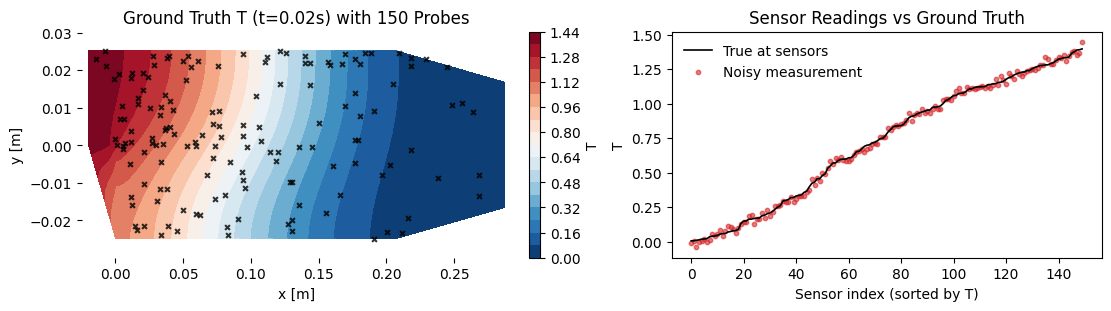

In [4]:
x = ds_true.x.values
y = ds_true.y.values

fig, axs = plt.subplots(1, 2, figsize=(11, 3), constrained_layout=True)

cs = axs[0].tricontourf(x, y, T_true, cmap='RdBu_r', levels=20)
axs[0].scatter(x[sensors], y[sensors], c='black', s=12, alpha=0.8, marker='x', label='Sensors')
axs[0].set_xlim([x.min() - 0.005, x.max() + 0.005])
axs[0].set_ylim([y.min() - 0.005, y.max() + 0.005])
axs[0].set_xlabel('x [m]')
axs[0].set_ylabel('y [m]')
axs[0].set_title(f'Ground Truth T (t=0.02s) with {N_SENSORS} Probes')
for spine in axs[0].spines.values():
    spine.set_visible(False)
cbar = fig.colorbar(cs, ax=axs[0], fraction=0.03, pad=0.04)
cbar.set_label('T')

sort_idx = np.argsort(T_true[sensors])
axs[1].plot(T_true[sensors][sort_idx], label='True at sensors', color='k', linewidth=1.2)
axs[1].scatter(np.arange(N_SENSORS), measured[sort_idx], color='tab:red', s=10, alpha=0.6, label='Noisy measurement')
axs[1].set_xlabel('Sensor index (sorted by T)')
axs[1].set_ylabel('T')
axs[1].set_title('Sensor Readings vs Ground Truth')
axs[1].legend(frameon=False)

plt.show()

## 3. Parameter optimization

Define the per-sensor residual vector with `as_residual` and solve using Levenberg-Marquardt least squares.

In [5]:
def residual_fn(ds):
    return ds['T'].values[-1][sensors] - measured

r = sim.as_residual(residual_fn=residual_fn, param_keys=[DT_KEY, TIN_KEY])

sim.reset()
result = least_squares(
    r,
    x0=[0.15, 1.0],
    bounds=([0.01, 0.5], [0.3, 3.0]),
    diff_step=1e-2
)

DT_fit, TIN_fit = result.x
print(f"           true      fitted     error")
print(f"DT         {DT_TRUE:<9.4f} {DT_fit:<10.4f} {abs(DT_fit - DT_TRUE) / DT_TRUE:.2%}")
print(f"Tin        {TIN_TRUE:<9.4f} {TIN_fit:<10.4f} {abs(TIN_fit - TIN_TRUE) / TIN_TRUE:.2%}")
print(f"\nsimulations {sim.run_count}")

           true      fitted     error
DT         0.0800    0.0812     1.47%
Tin        1.4000    1.4011     0.08%

simulations 19


## 4. Fit verification and field reconstruction

Compare predicted sensor values against measurements, and reconstruct the full 2D field across all 12,225 cells.

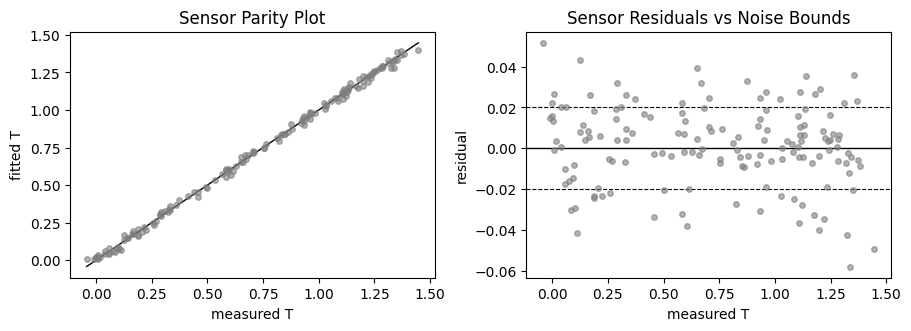

rms residual   0.0198
noise added    0.0200


In [6]:
ds_fit = sim.run({DT_KEY: DT_fit, TIN_KEY: TIN_fit})
T_fit = ds_fit['T'].values[-1]
predicted = T_fit[sensors]
residuals = predicted - measured

fig, axs = plt.subplots(1, 2, figsize=(9, 3.2), constrained_layout=True)

lims = [min(measured.min(), predicted.min()), max(measured.max(), predicted.max())]
axs[0].plot(lims, lims, '-', color='k', linewidth=1)
axs[0].plot(measured, predicted, 'o', color='tab:gray', alpha=0.6, markersize=4)
axs[0].set_xlabel('measured T')
axs[0].set_ylabel('fitted T')
axs[0].set_title('Sensor Parity Plot')

axs[1].axhline(0, color='k', linewidth=1)
axs[1].axhline(NOISE, color='k', linestyle='--', linewidth=0.8)
axs[1].axhline(-NOISE, color='k', linestyle='--', linewidth=0.8)
axs[1].plot(measured, residuals, 'o', color='tab:gray', alpha=0.6, markersize=4)
axs[1].set_xlabel('measured T')
axs[1].set_ylabel('residual')
axs[1].set_title('Sensor Residuals vs Noise Bounds')

plt.show()

print(f"rms residual   {np.sqrt(np.mean(residuals ** 2)):.4f}")
print(f"noise added    {NOISE:.4f}")

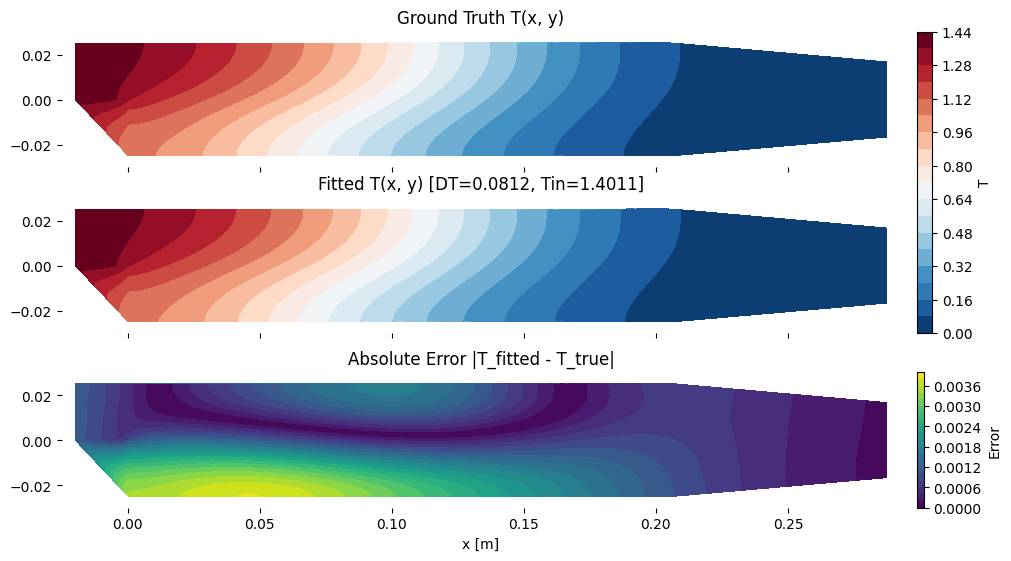

Max domain error:  3.8080e-03
Mean domain error: 1.2452e-03


In [7]:
error_field = np.abs(T_fit - T_true)

fig, axs = plt.subplots(3, 1, figsize=(10, 5.5), sharex=True, sharey=True, constrained_layout=True)

vmin, vmax = min(T_true.min(), T_fit.min()), max(T_true.max(), T_fit.max())

cs0 = axs[0].tricontourf(x, y, T_true, cmap='RdBu_r', levels=20, vmin=vmin, vmax=vmax)
axs[0].set_title('Ground Truth T(x, y)')
for spine in axs[0].spines.values():
    spine.set_visible(False)

cs1 = axs[1].tricontourf(x, y, T_fit, cmap='RdBu_r', levels=20, vmin=vmin, vmax=vmax)
axs[1].set_title(f'Fitted T(x, y) [DT={DT_fit:.4f}, Tin={TIN_fit:.4f}]')
for spine in axs[1].spines.values():
    spine.set_visible(False)

cs2 = axs[2].tricontourf(x, y, error_field, cmap='viridis', levels=20)
axs[2].set_title('Absolute Error |T_fitted - T_true|')
axs[2].set_xlabel('x [m]')
for spine in axs[2].spines.values():
    spine.set_visible(False)

axs[0].set_xlim([x.min() - 0.005, x.max() + 0.005])
axs[0].set_ylim([y.min() - 0.005, y.max() + 0.005])

cbar_T = fig.colorbar(cs0, ax=axs[:2], fraction=0.02, pad=0.02)
cbar_T.set_label('T')

cbar_err = fig.colorbar(cs2, ax=axs[2], fraction=0.02, pad=0.02)
cbar_err.set_label('Error')

plt.show()

print(f"Max domain error:  {error_field.max():.4e}")
print(f"Mean domain error: {error_field.mean():.4e}")